In [7]:
# 시청 기록 파일 가져오기
import pandas as pd
import json

df=pd.read_json("시청 기록.json")

In [8]:
# 데이터 수정 => 최적화.
df.drop(columns= ["header","titleUrl","products","activityControls"], inplace = True)


In [9]:
# column 내 필요 없는 문자 대
df["title"]=df["title"].str.replace("을(를) 시청했습니다.","")
df

,title,subtitles,time
0,[𝙋𝙡𝙖𝙮𝙡𝙞𝙨𝙩] 상실의 시대…내가 사랑한 나의 미도리 | 감성 피아노,"[{'name': '노르웨이 숲 Norwegian Wood', 'url': 'htt...",2026-02-04T04:14:52.157Z
1,"과거에는 컴퓨터를 쓰기 위해 복잡한 코딩을 배워야 했지만, 이제는 컴퓨터랑 대화만 ...","[{'name': 'BZCF | 비즈까페', 'url': 'https://www.y...",2026-02-04T04:13:55.202Z
2,요즘 생각 : 너무 빠르고 무섭고 걱정도되고 슬프기도 하고 할수있는 것은 없고 그렇...,"[{'name': 'BZCF | 비즈까페', 'url': 'https://www.y...",2026-02-04T04:13:55.202Z
3,Blue Bird (2022 ver.) - Naruto Shippuuden OP3 ...,"[{'name': 'Animenz Piano Sheets', 'url': 'http...",2026-02-03T23:31:08.546Z
4,TWO-lives,"[{'name': 'Hiroyuki SAWANO - Topic', 'url': 'h...",2026-02-03T23:21:00.923Z
...,...,...,...
13043,승준이 우유 대소동,"[{'name': '동수칸TV', 'url': 'https://www.youtube...",2025-11-06T13:00:24.178Z
13044,레전드 사건 발생 ㅋㅋㅋㅋㅋㅋ,"[{'name': '동수칸TV', 'url': 'https://www.youtube...",2025-11-06T12:57:02.711Z
13045,의문의 중고차 딜러,"[{'name': '동수칸TV', 'url': 'https://www.youtube...",2025-11-06T12:43:57.489Z
13046,첫 번째 레슨,"[{'name': '동수칸TV', 'url': 'https://www.youtube...",2025-11-06T12:24:23.712Z


isinstance(sub_list,list) => sub_list라는 변수에 들어온 녀석이 리스트[] 자료형인지 확인한다.
isinstance(확인하고자 하는 데이터 값, 확인하고자 하는 데이터 타입) => True or False
len(sub_list) > 0 => 아예 없는 경우 방지(안전장치)

sub_list[0] 리스트의 1번째 칸에 있는 딕셔너리{} 선택
get('name') => name이라는 key에 연결된 값(채널명)을 가져온다.


In [10]:
# 채널 이름 추출
def extract_channel(sub_list):
    if isinstance(sub_list, list) and len(sub_list)>0:
        return sub_list[0].get("name")
    return "Unknown"

df["channel"] = df["subtitles"].apply(extract_channel)
df

,title,subtitles,time,channel
0,[𝙋𝙡𝙖𝙮𝙡𝙞𝙨𝙩] 상실의 시대…내가 사랑한 나의 미도리 | 감성 피아노,"[{'name': '노르웨이 숲 Norwegian Wood', 'url': 'htt...",2026-02-04T04:14:52.157Z,노르웨이 숲 Norwegian Wood
1,"과거에는 컴퓨터를 쓰기 위해 복잡한 코딩을 배워야 했지만, 이제는 컴퓨터랑 대화만 ...","[{'name': 'BZCF | 비즈까페', 'url': 'https://www.y...",2026-02-04T04:13:55.202Z,BZCF | 비즈까페
2,요즘 생각 : 너무 빠르고 무섭고 걱정도되고 슬프기도 하고 할수있는 것은 없고 그렇...,"[{'name': 'BZCF | 비즈까페', 'url': 'https://www.y...",2026-02-04T04:13:55.202Z,BZCF | 비즈까페
3,Blue Bird (2022 ver.) - Naruto Shippuuden OP3 ...,"[{'name': 'Animenz Piano Sheets', 'url': 'http...",2026-02-03T23:31:08.546Z,Animenz Piano Sheets
4,TWO-lives,"[{'name': 'Hiroyuki SAWANO - Topic', 'url': 'h...",2026-02-03T23:21:00.923Z,Hiroyuki SAWANO - Topic
...,...,...,...,...
13043,승준이 우유 대소동,"[{'name': '동수칸TV', 'url': 'https://www.youtube...",2025-11-06T13:00:24.178Z,동수칸TV
13044,레전드 사건 발생 ㅋㅋㅋㅋㅋㅋ,"[{'name': '동수칸TV', 'url': 'https://www.youtube...",2025-11-06T12:57:02.711Z,동수칸TV
13045,의문의 중고차 딜러,"[{'name': '동수칸TV', 'url': 'https://www.youtube...",2025-11-06T12:43:57.489Z,동수칸TV
13046,첫 번째 레슨,"[{'name': '동수칸TV', 'url': 'https://www.youtube...",2025-11-06T12:24:23.712Z,동수칸TV


In [11]:
# 기존 데이터 삭제
df.drop(columns=["subtitles"], inplace = True)
df

,title,time,channel
0,[𝙋𝙡𝙖𝙮𝙡𝙞𝙨𝙩] 상실의 시대…내가 사랑한 나의 미도리 | 감성 피아노,2026-02-04T04:14:52.157Z,노르웨이 숲 Norwegian Wood
1,"과거에는 컴퓨터를 쓰기 위해 복잡한 코딩을 배워야 했지만, 이제는 컴퓨터랑 대화만 ...",2026-02-04T04:13:55.202Z,BZCF | 비즈까페
2,요즘 생각 : 너무 빠르고 무섭고 걱정도되고 슬프기도 하고 할수있는 것은 없고 그렇...,2026-02-04T04:13:55.202Z,BZCF | 비즈까페
3,Blue Bird (2022 ver.) - Naruto Shippuuden OP3 ...,2026-02-03T23:31:08.546Z,Animenz Piano Sheets
4,TWO-lives,2026-02-03T23:21:00.923Z,Hiroyuki SAWANO - Topic
...,...,...,...
13043,승준이 우유 대소동,2025-11-06T13:00:24.178Z,동수칸TV
13044,레전드 사건 발생 ㅋㅋㅋㅋㅋㅋ,2025-11-06T12:57:02.711Z,동수칸TV
13045,의문의 중고차 딜러,2025-11-06T12:43:57.489Z,동수칸TV
13046,첫 번째 레슨,2025-11-06T12:24:23.712Z,동수칸TV


to_datetime => 문자열이었던 시간을 datetime 자료형으로 전환한다. 만약 시간 형식이 제각각이라면
format = 'mixed' / utc값으로 시작한다 확정짓고

한국시간을 위해. dt.tz_convert("Asia/Seoul")로 변경  만약 다른 나라 Asia/Tokyo

In [12]:
#문자열을 날짜/시간 각체로 변환(UTC 기능)
df['time']=pd.to_datetime(df['time'], format ='mixed', utc =True)

df['time_kst']=df['time'].dt.tz_convert("Asia/Seoul")

#년,월, 일, 시, 요일 따로 추출
df['year']= df['time_kst'].dt.year
df['month']=df['time_kst'].dt.month
df['day'] = df['time_kst'].dt.day
df['hour'] = df['time_kst'].dt.hour
df['hour']=df['hour']-9
df["minute"]=df["time_kst"].dt.minute
df['weekday']=df['time_kst'].dt.day_name()


In [24]:
# 먼저 어떤 channel을 많이 봤는지 분석
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"]= False

In [25]:
df.sort_values("year",ascending=True)


,title,time,channel,time_kst,year,month,day,hour,minute,weekday
6523,홈짐에 3200만원을 태워..!? 헬스장 뺨치는 홈짐리뷰,2025-12-25 08:27:45.087000+00:00,지피티,2025-12-25 17:27:45.087000+09:00,2025,12,25,8,27,Thursday
8692,후드영어 vs 교양영어 비교,2025-12-09 13:17:00.761000+00:00,칠성레이블,2025-12-09 22:17:00.761000+09:00,2025,12,9,13,17,Tuesday
8693,이노래 때문에 한동안 1위를 못한 빌보드 명곡 TOP5,2025-12-09 13:16:54.533000+00:00,한입만,2025-12-09 22:16:54.533000+09:00,2025,12,9,13,16,Tuesday
8694,라캄파넬라가 어려운 진짜 이유는? #피아노 #피아노연주,2025-12-09 13:16:53.446000+00:00,1분악기,2025-12-09 22:16:53.446000+09:00,2025,12,9,13,16,Tuesday
8695,캐논으로 들어보는 다양한 박자 1편 #캐논 #음악 #박자,2025-12-09 13:16:32.773000+00:00,리히트 음악실,2025-12-09 22:16:32.773000+09:00,2025,12,9,13,16,Tuesday
...,...,...,...,...,...,...,...,...,...,...
3560,#남자펌 은 볼륨만 넣고 자연스럽게 c컬 #남자볼륨펌 추천 #시스루뱅 #남자머리추천,2026-01-11 07:41:17.548000+00:00,There_c 대열씨,2026-01-11 16:41:17.548000+09:00,2026,1,11,7,41,Sunday
3561,요리 천재들 현타오게 하는 선재스님의 요리실력 ㄷㄷㄷ,2026-01-11 06:02:43.282000+00:00,하탄방,2026-01-11 15:02:43.282000+09:00,2026,1,11,6,2,Sunday
3562,1박 2일 이수근 예능감ㅋㅋ,2026-01-11 06:02:05.330000+00:00,esports KBS,2026-01-11 15:02:05.330000+09:00,2026,1,11,6,2,Sunday
3564,https://www.youtube.com/watch?v=qoAENQ8NtIQ,2026-01-11 06:01:26.141000+00:00,Unknown,2026-01-11 15:01:26.141000+09:00,2026,1,11,6,1,Sunday


In [26]:
channel_sort=df.groupby(["channel"]).size().reset_index(name ="count")
## reset_index(name ="")  판다스의 size를 본다면 이는 series 형태이다. 이를 DataFrame형태로 바꾸기 위해서는
## reset_index를 작성하는 것 (column 이름은 따로 지정이 가능하다.)
print(channel_sort)

                  channel  count
0        Allright24_박재훈    138
1                  고기남자      1
2                   오띵스      1
3                      딴짓      2
4      Showboating_Boxing      1
...                   ...    ...
3661                  힙으뜸      2
3662                  힙플밈      8
3663   힙한루피 hipster loopy      1
3664     𝕋𝕙𝕖 𝕝𝕒𝕤𝕥 𝕙𝕠𝕦𝕣𝕤 🌊      1
3665                🚨티방위🚨      1

[3666 rows x 2 columns]


In [93]:
channel_sort.sort_values("count",ascending = False, inplace=True)

idx = channel_sort[channel_sort["channel"]=="Unknown"].index
channel_sort.drop(idx, inplace =True)
# 그 중 이상한 데이터 Unknown 삭제

Top_50 = channel_sort.head(50).copy()
# Top 50개만 본다.
# copy본으로 만든다.

Top_50.sort_values("count",ascending = True, inplace =True)

In [106]:
matplotlib.rcParams["font.size"] = 5

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_2720\6500689.py:10: UserWarning: Glyph 8 ) missing from font(s) Malgun Gothic.
  plt.savefig("Youtube_50.jpg",dpi = 300)
C:\Users\EZEN\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8 ) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


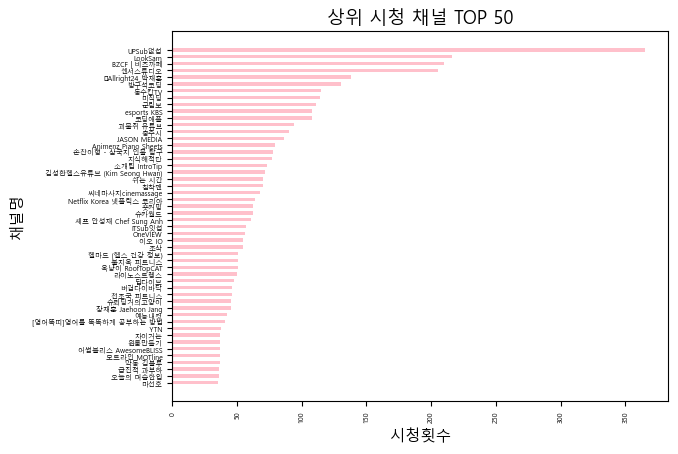

In [118]:
plt.barh(Top_50["channel"],Top_50["count"],height  =0.5,color = "pink")
# 가로 그래프 만들기 / 그래프 두께 / 컬러
plt.title("상위 시청 채널 TOP 50", fontsize = 13)
# 타이틀
plt.xticks(rotation = 90)
# 채널명 회전시키기
plt.xlabel("시청횟수", fontsize = 11)
plt.ylabel("채널명", fontsize = 11)
# x,y축 이름 붙이기
plt.savefig("Youtube_50.jpg",dpi = 300)